In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

VERDE  = '#2D6A4F'
VERDE2 = '#40916C'
VERDE3 = '#74C69D'
AMBER  = '#E9C46A'
CORAL  = '#E76F51'
GRIS   = '#6C757D'
PALETTE = [VERDE, VERDE2, VERDE3, AMBER, CORAL, '#264653', '#F4A261', '#A8DADC']

# Rutas absolutas — funcionan desde cualquier ubicación
BASE    = r"C:\Users\Usuario\Coffe-ops-eda-analysis\data\processed" + "\\"
OUTPUT  = r"C:\Users\Usuario\Coffe-ops-eda-analysis\output" + "\\"

df_items   = pd.read_csv(BASE + "items_clean.csv",       parse_dates=['fecha'])
df_trans   = pd.read_csv(BASE + "transacciones_clean.csv", parse_dates=['fecha'])
df_conteo  = pd.read_csv(BASE + "items_conteo_clean.csv")
df_secc    = pd.read_csv(BASE + "secciones_clean.csv")
df_egresos = pd.read_csv(BASE + "egresos_clean.csv")

print("Datos cargados correctamente")
print(f"  Items: {len(df_items):,} filas")
print(f"  Transacciones: {len(df_trans):,} filas")
print(f"  Período: {df_items['fecha'].min().date()} → {df_items['fecha'].max().date()}")

Datos cargados correctamente
  Items: 25,559 filas
  Transacciones: 10,023 filas
  Período: 2024-04-08 → 2024-12-31


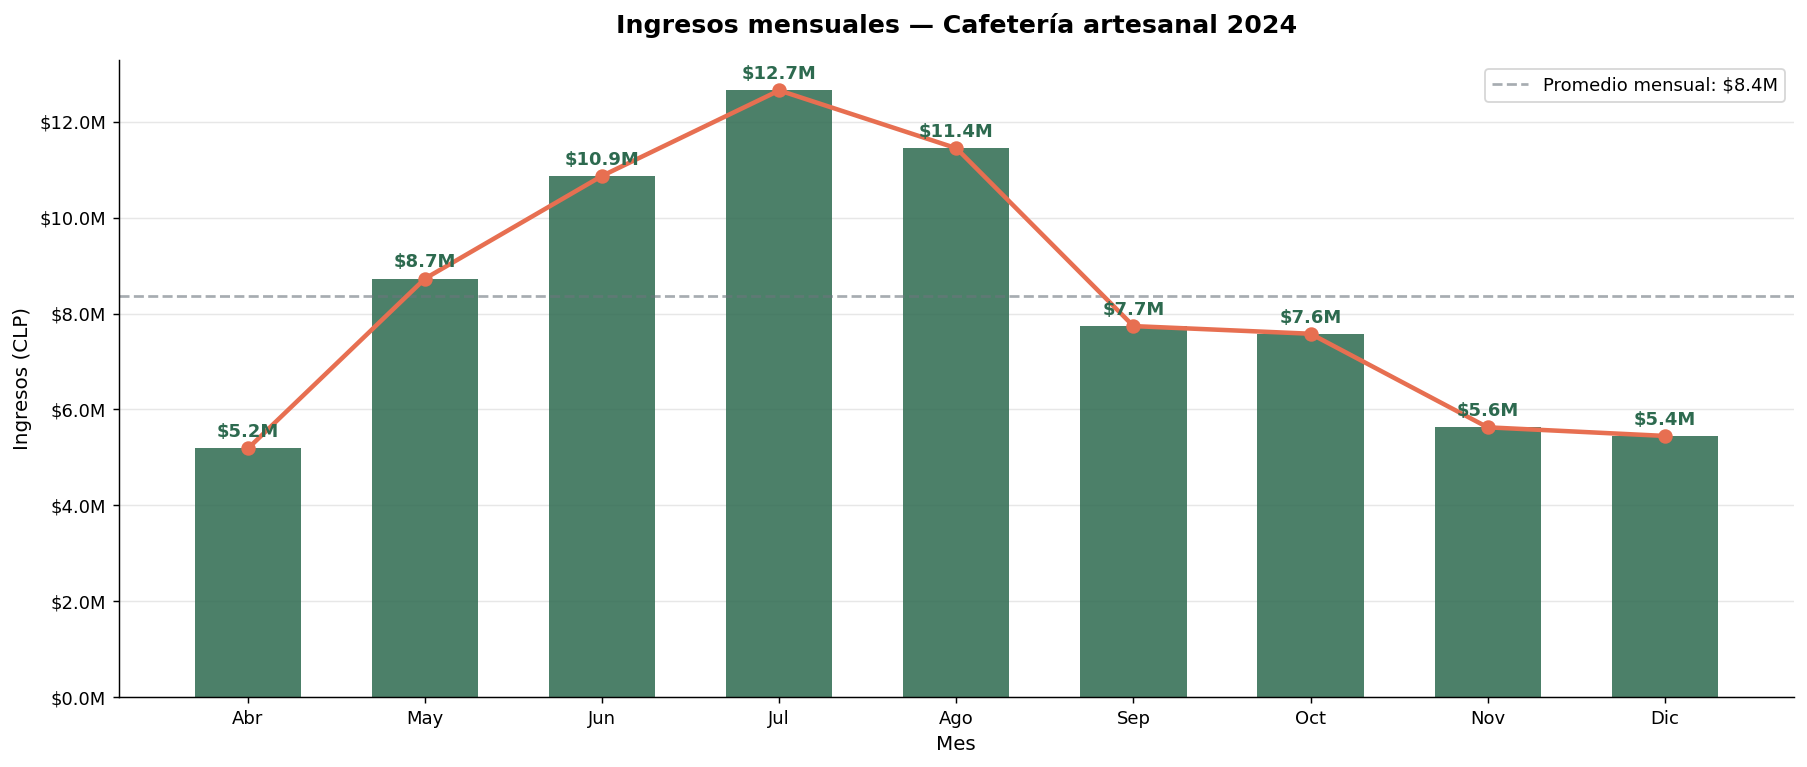

Ingresos totales: $75,280,539 CLP
Mejor mes: Jul ($12,653,159)
Mes más bajo: Abr ($5,186,882)


In [18]:
# ============================================================
# 2 — Tendencia de ingresos mensual
# ============================================================
ingresos_mensual = df_items.groupby(
    df_items['fecha'].dt.to_period('M'))['revenue'].sum()
ingresos_mensual.index = ingresos_mensual.index.astype(str)

meses_es = {
    '2024-04': 'Abr', '2024-05': 'May', '2024-06': 'Jun',
    '2024-07': 'Jul', '2024-08': 'Ago', '2024-09': 'Sep',
    '2024-10': 'Oct', '2024-11': 'Nov', '2024-12': 'Dic'
}
ingresos_mensual.index = [meses_es.get(i, i) for i in ingresos_mensual.index]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(ingresos_mensual.index, ingresos_mensual.values,
              color=VERDE, alpha=0.85, width=0.6, zorder=2)
ax.plot(ingresos_mensual.index, ingresos_mensual.values,
        color=CORAL, marker='o', linewidth=2.5, markersize=7, zorder=3)

for bar, val in zip(bars, ingresos_mensual.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150000,
            f'${val/1e6:.1f}M', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color=VERDE)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.set_title('Ingresos mensuales — Cafetería artesanal 2024',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Mes', fontsize=11)
ax.set_ylabel('Ingresos (CLP)', fontsize=11)
ax.axhline(ingresos_mensual.mean(), color=GRIS, linestyle='--', alpha=0.6,
           label=f'Promedio mensual: ${ingresos_mensual.mean()/1e6:.1f}M')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3, zorder=1)
plt.tight_layout()
plt.savefig(OUTPUT + '01_ingresos_mensual.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Ingresos totales: ${ingresos_mensual.sum():,.0f} CLP")
print(f"Mejor mes: {ingresos_mensual.idxmax()} (${ingresos_mensual.max():,.0f})")
print(f"Mes más bajo: {ingresos_mensual.idxmin()} (${ingresos_mensual.min():,.0f})")

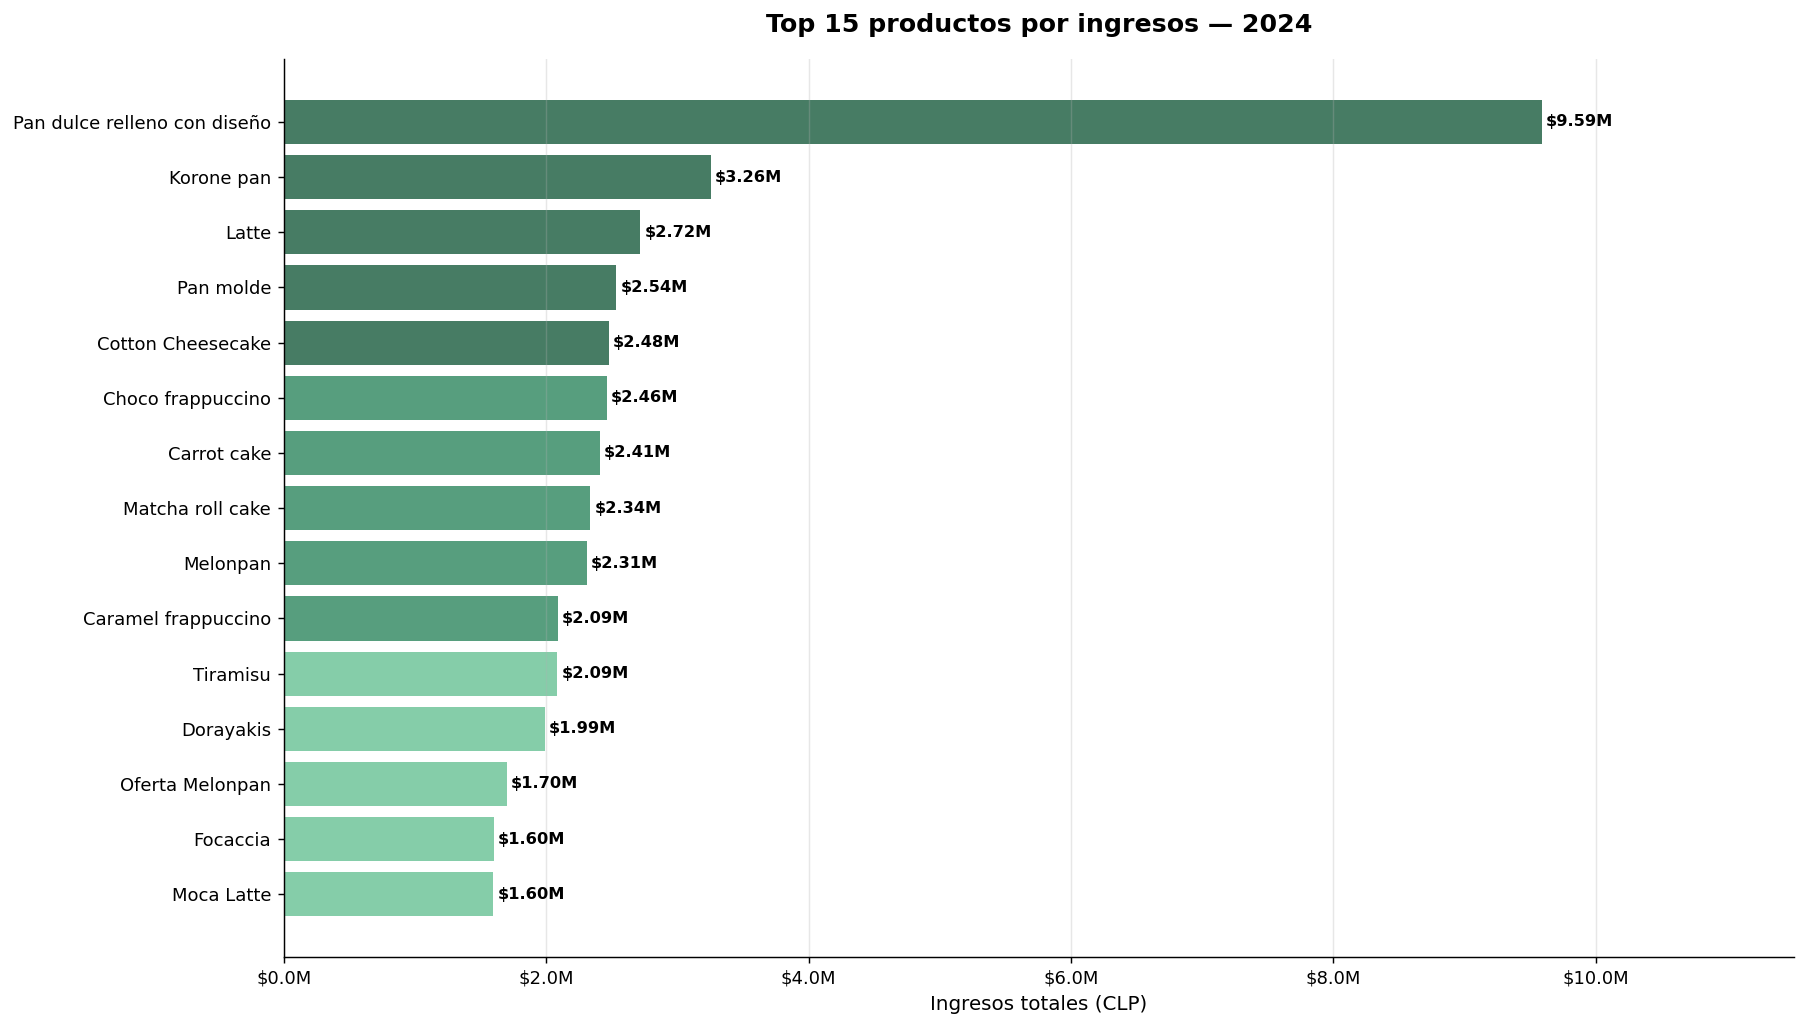

In [19]:
# ============================================================
# 3 — Top 15 productos por ingresos
# ============================================================
# Excluir mayoristas y ofertas para el análisis de menú unitario
excluir = ['Tiramisu stevia x 20', 'Ley Redondeo']
top15 = df_conteo[~df_conteo['producto'].isin(excluir)].head(15).copy()

fig, ax = plt.subplots(figsize=(14, 8))
colors = [VERDE if i < 5 else VERDE2 if i < 10 else VERDE3 for i in range(len(top15))]
bars = ax.barh(top15['producto'], top15['total'], color=colors, alpha=0.88)

for bar, val in zip(bars, top15['total']):
    ax.text(bar.get_width() + 30000, bar.get_y() + bar.get_height()/2,
            f'${val/1e6:.2f}M', va='center', fontsize=9, fontweight='bold')

ax.set_xlim(0, top15['total'].max() * 1.2)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.set_title('Top 15 productos por ingresos — 2024', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Ingresos totales (CLP)', fontsize=11)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT + '02_top15_productos.png', dpi=150, bbox_inches='tight')
plt.show()

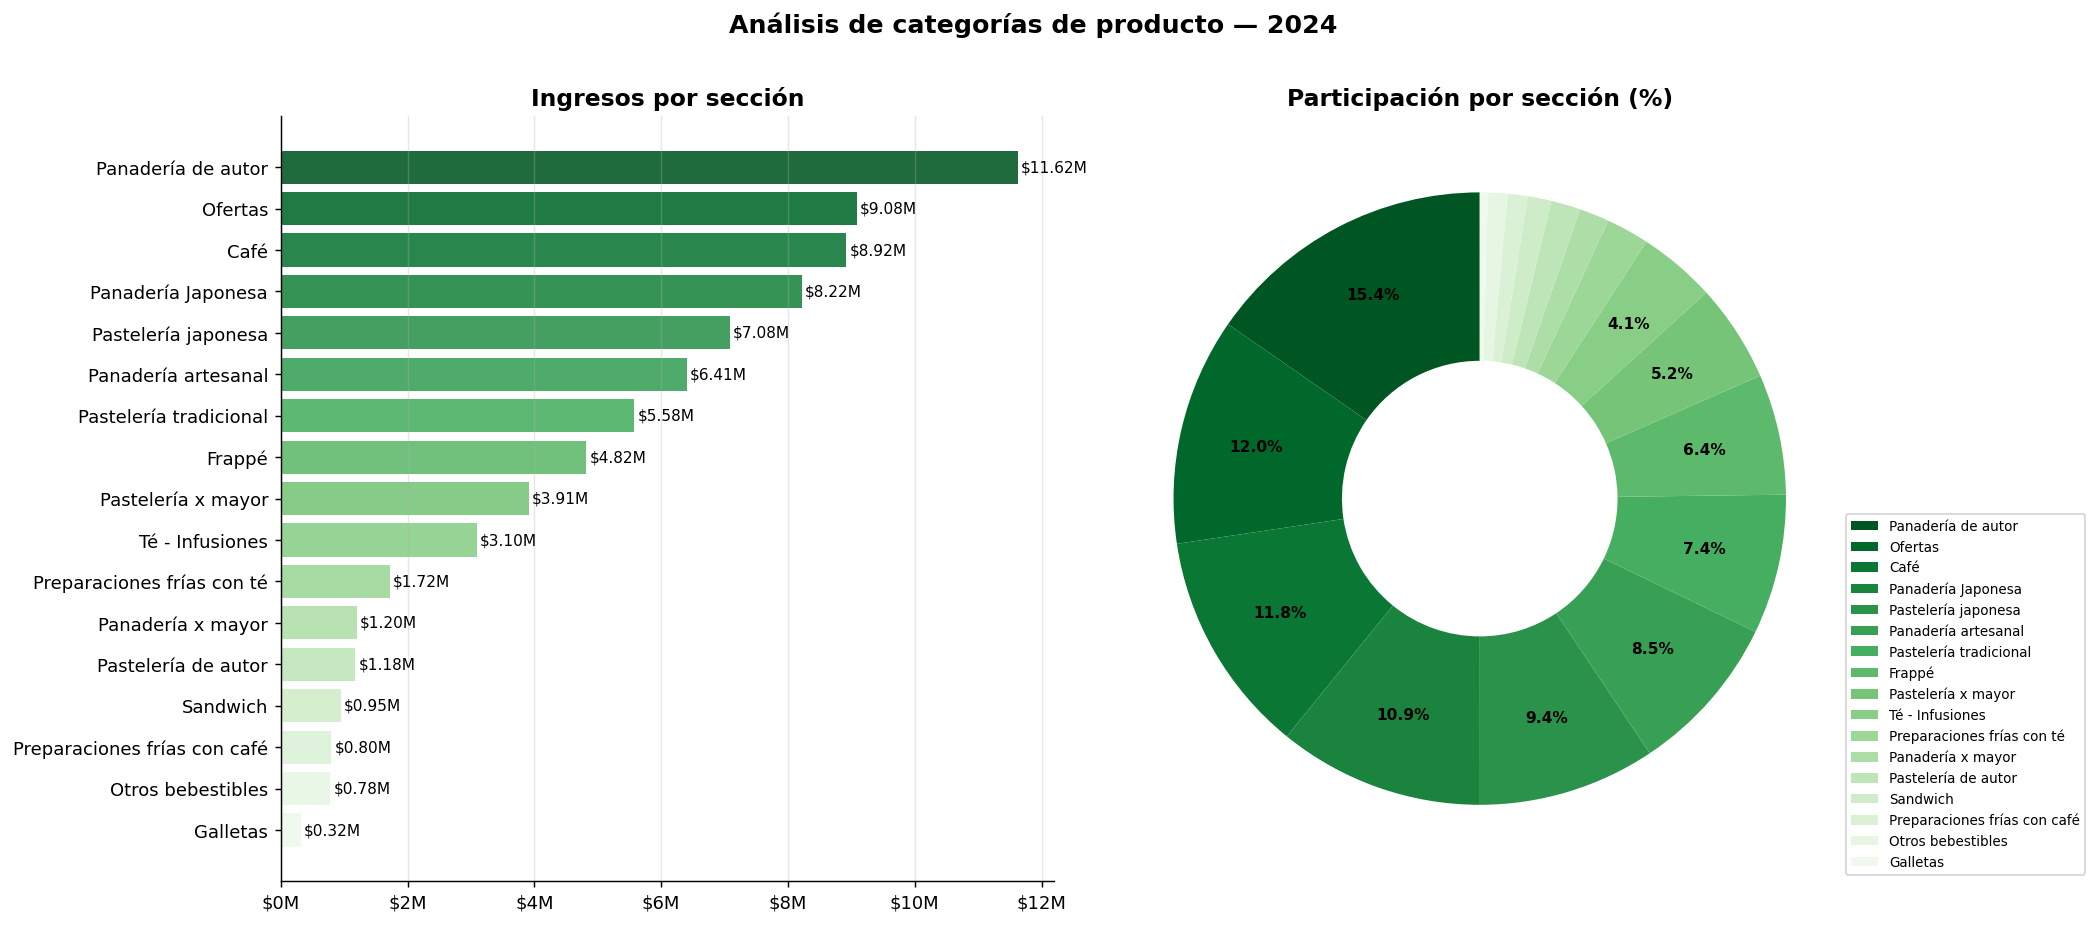

In [20]:
# ============================================================
# 4 — Ingresos por sección (categoría de producto)
# ============================================================
# Filtrar secciones muy pequeñas para claridad visual
secc_filtrada = df_secc[df_secc['total'] > 100000].copy()
secc_filtrada = secc_filtrada.sort_values('total', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Gráfico de barras horizontal
palette_secc = sns.color_palette("Greens_r", len(secc_filtrada))
bars = ax1.barh(secc_filtrada['seccion'], secc_filtrada['total'],
                color=palette_secc, alpha=0.88)
for bar, val in zip(bars, secc_filtrada['total']):
    ax1.text(bar.get_width() + 50000, bar.get_y() + bar.get_height()/2,
             f'${val/1e6:.2f}M', va='center', fontsize=8.5)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
ax1.set_title('Ingresos por sección', fontsize=13, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# Gráfico de dona (participación %)
wedges, texts, autotexts = ax2.pie(
    secc_filtrada['total'],
    labels=None,
    autopct=lambda p: f'{p:.1f}%' if p > 3 else '',
    colors=sns.color_palette("Greens_r", len(secc_filtrada)),
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.55)
)
for at in autotexts:
    at.set_fontsize(8.5)
    at.set_fontweight('bold')
ax2.legend(secc_filtrada['seccion'], loc='lower right',
           fontsize=7.5, bbox_to_anchor=(1.3, 0))
ax2.set_title('Participación por sección (%)', fontsize=13, fontweight='bold')

plt.suptitle('Análisis de categorías de producto — 2024', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT + '03_ingresos_por_seccion.png', dpi=150, bbox_inches='tight')
plt.show()

Hora de mayor ingreso: 18h
Día de mayor ingreso: sábado


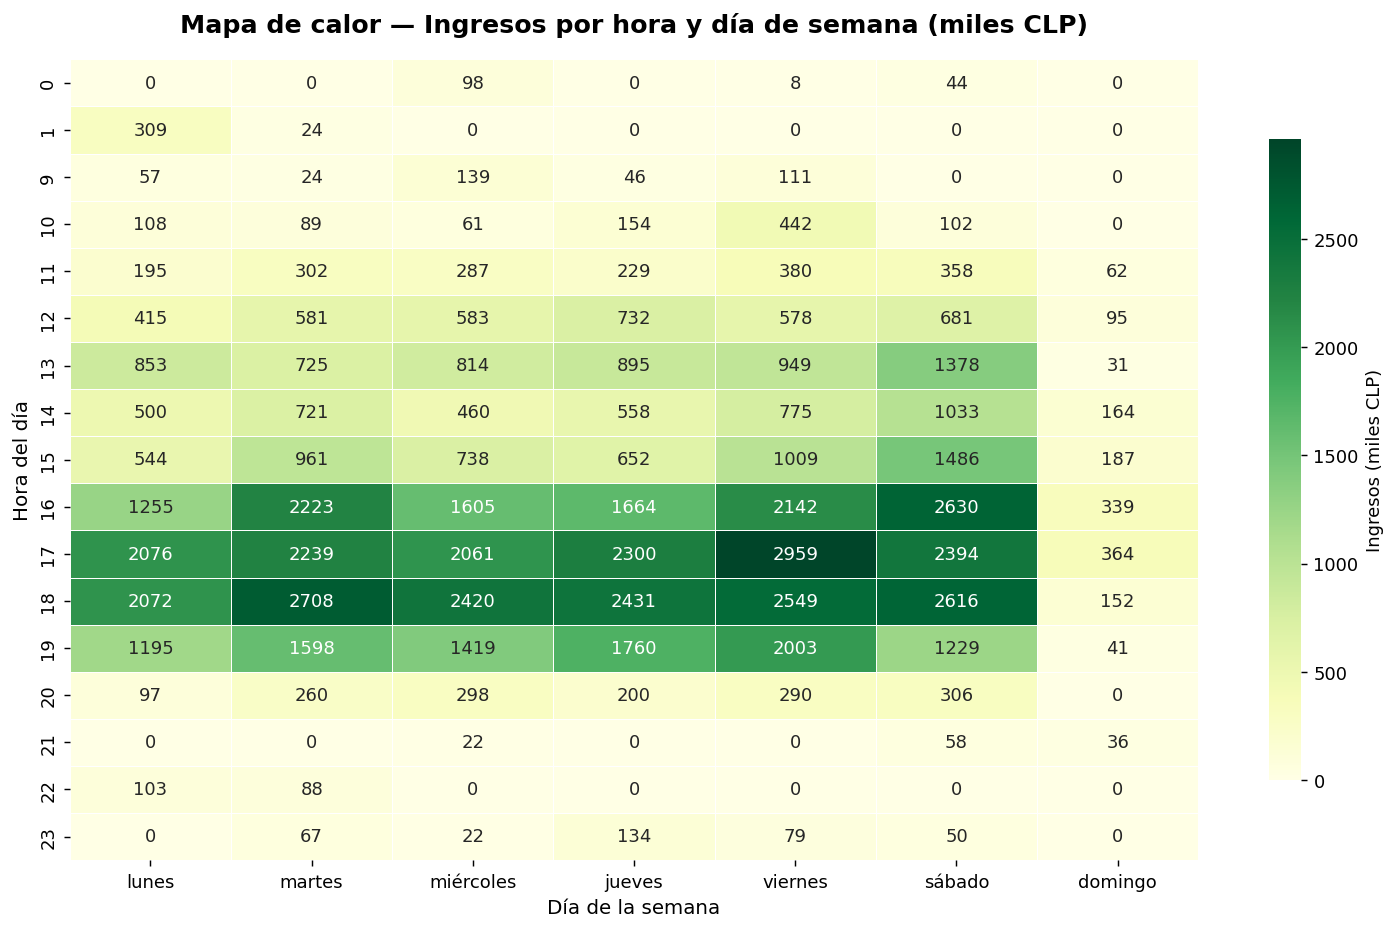

In [21]:
# ============================================================
# 5 — Heatmap de tráfico por hora y día de semana
# ============================================================
orden_dias = ['lunes','martes','miércoles','jueves','viernes','sábado','domingo']
df_items['dia_semana_str'] = df_items['dia_semana'].str.lower().str.strip()

pivot = df_items.pivot_table(
    index='hora',
    columns='dia_semana_str',
    values='revenue',
    aggfunc='sum'
)
# Reordenar columnas en orden lógico
cols_presentes = [d for d in orden_dias if d in pivot.columns]
pivot = pivot[cols_presentes]
pivot = pivot.fillna(0) / 1e3  # en miles de CLP

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    pivot,
    cmap='YlGn',
    annot=True,
    fmt='.0f',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Ingresos (miles CLP)', 'shrink': 0.8}
)
ax.set_title('Mapa de calor — Ingresos por hora y día de semana (miles CLP)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Día de la semana', fontsize=11)
ax.set_ylabel('Hora del día', fontsize=11)
# En el cbar_kws:
cbar_kws={'label': 'Ingresos (miles CLP)', 'shrink': 0.8}
# El print al final:
print(f"Hora de mayor ingreso: {pivot.sum(axis=1).idxmax()}h")
print(f"Día de mayor ingreso: {pivot.sum(axis=0).idxmax()}")

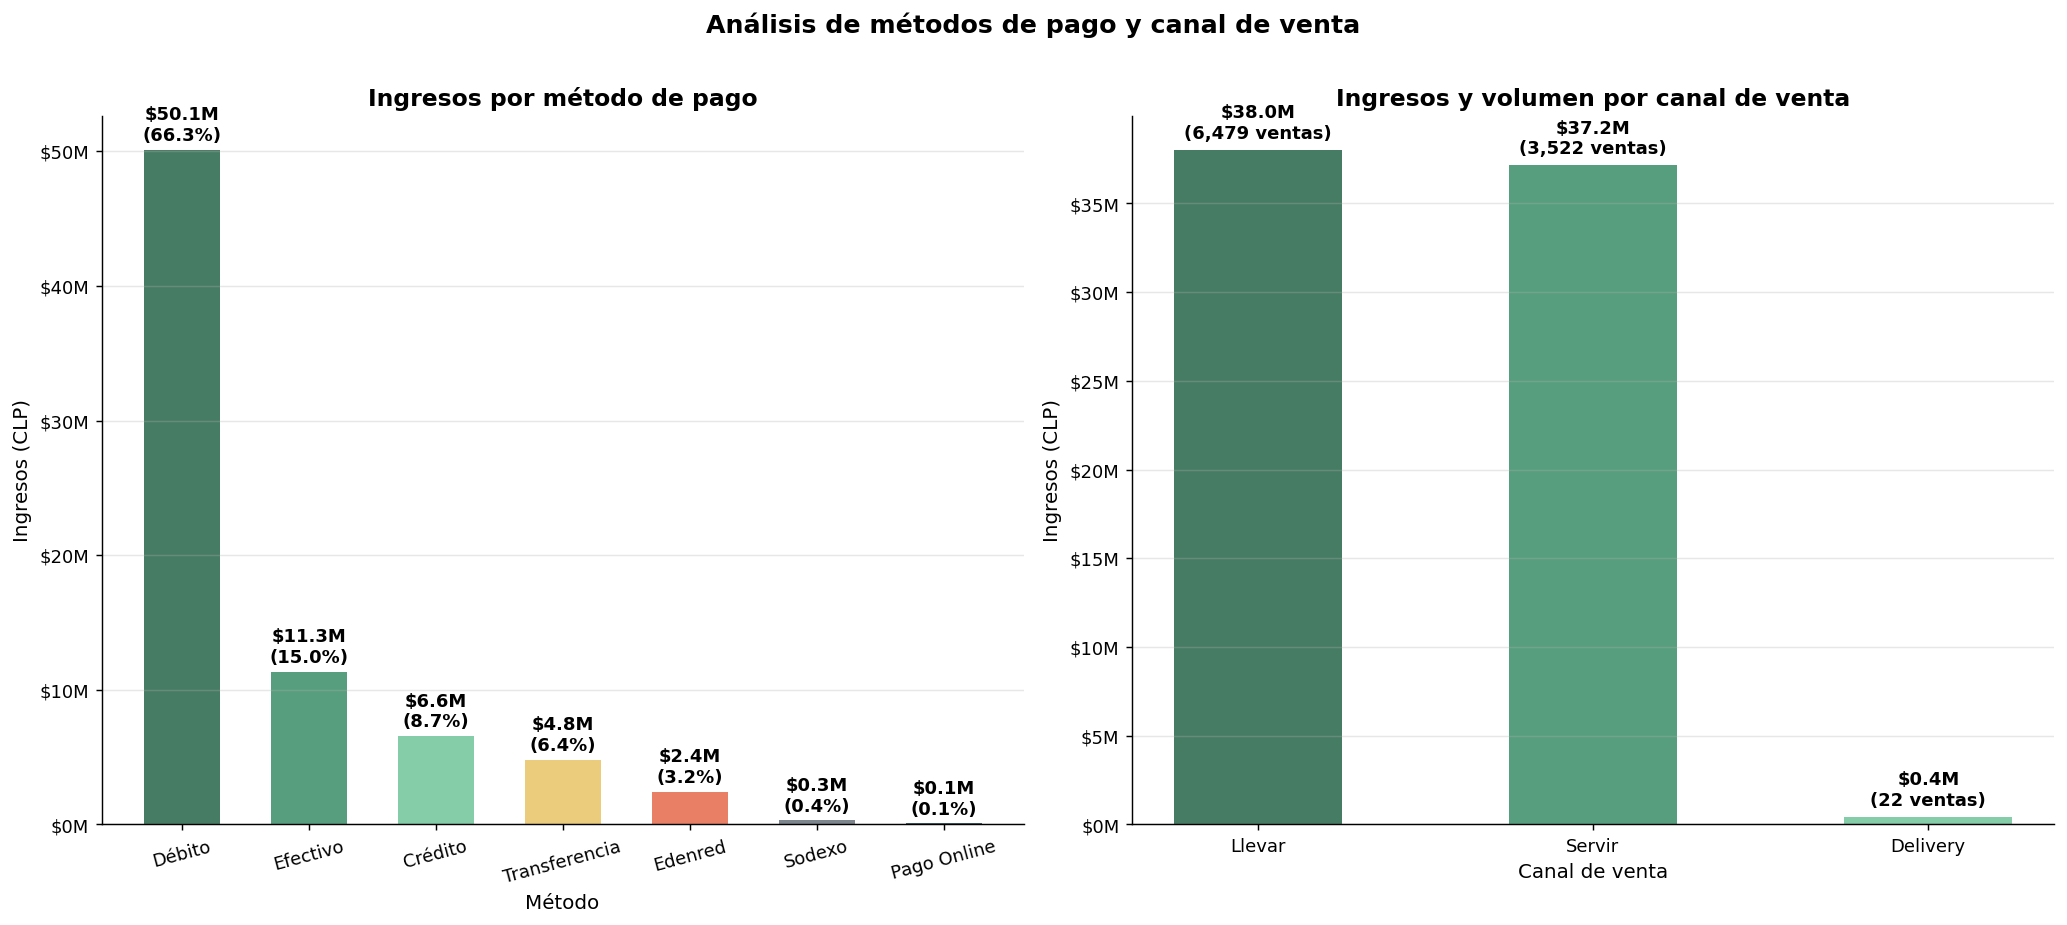

Desglose por método de pago:
  Débito          $  50,128,798 (66.3%)
  Efectivo        $  11,345,030 (15.0%)
  Crédito         $   6,556,625 (8.7%)
  Transferencia   $   4,823,015 (6.4%)
  Edenred         $   2,405,200 (3.2%)
  Sodexo          $     305,500 (0.4%)
  Pago Online     $      84,320 (0.1%)


In [22]:
# ============================================================
# 6 — Métodos de pago y tipo de venta
# ============================================================

# Limpiar métodos de pago — quedarse solo con el método principal
def simplificar_pago(metodo):
    if pd.isna(metodo): return 'Otro'
    m = str(metodo).strip()
    if 'Débito'       in m: return 'Débito'
    if 'Efectivo'     in m: return 'Efectivo'
    if 'Crédito'      in m: return 'Crédito'
    if 'Transferencia' in m: return 'Transferencia'
    if 'Edenred'      in m: return 'Edenred'
    if 'Sodexo'       in m: return 'Sodexo'
    if 'Online'       in m: return 'Pago Online'
    return 'Otro'

df_trans['metodo_simple'] = df_trans['metodo_pago'].apply(simplificar_pago)

pago = df_trans.groupby('metodo_simple')['total'].sum().sort_values(ascending=False)
pago_pct = (pago / pago.sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Izquierda: Métodos de pago ---
colors_pago = [VERDE, VERDE2, VERDE3, AMBER, CORAL, GRIS, '#264653'][:len(pago)]
bars = axes[0].bar(pago.index, pago.values, color=colors_pago, alpha=0.88, width=0.6)

for bar, val, pct in zip(bars, pago.values, pago_pct.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 400000,
        f'${val/1e6:.1f}M\n({pct}%)',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
axes[0].set_title('Ingresos por método de pago', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Método', fontsize=11)
axes[0].set_ylabel('Ingresos (CLP)', fontsize=11)
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3)

# --- Derecha: Tipo de venta ---
tipo = df_trans.groupby('tipo_venta')['total'].agg(['sum','count'])
tipo.columns = ['ingresos','transacciones']
tipo = tipo.sort_values('ingresos', ascending=False)

colors_tipo = [VERDE, VERDE2, VERDE3, AMBER][:len(tipo)]
bars2 = axes[1].bar(tipo.index, tipo['ingresos'],
                    color=colors_tipo, alpha=0.88, width=0.5)

for bar, (idx, row) in zip(bars2, tipo.iterrows()):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 400000,
        f'${row["ingresos"]/1e6:.1f}M\n({row["transacciones"]:,} ventas)',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
axes[1].set_title('Ingresos y volumen por canal de venta', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Canal de venta', fontsize=11)
axes[1].set_ylabel('Ingresos (CLP)', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Análisis de métodos de pago y canal de venta',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT + '05_pago_y_tipo_venta.png', dpi=150, bbox_inches='tight')
plt.show()

print("Desglose por método de pago:")
for metodo, val in pago.items():
    print(f"  {metodo:<15} ${val:>12,.0f} ({pago_pct[metodo]}%)")

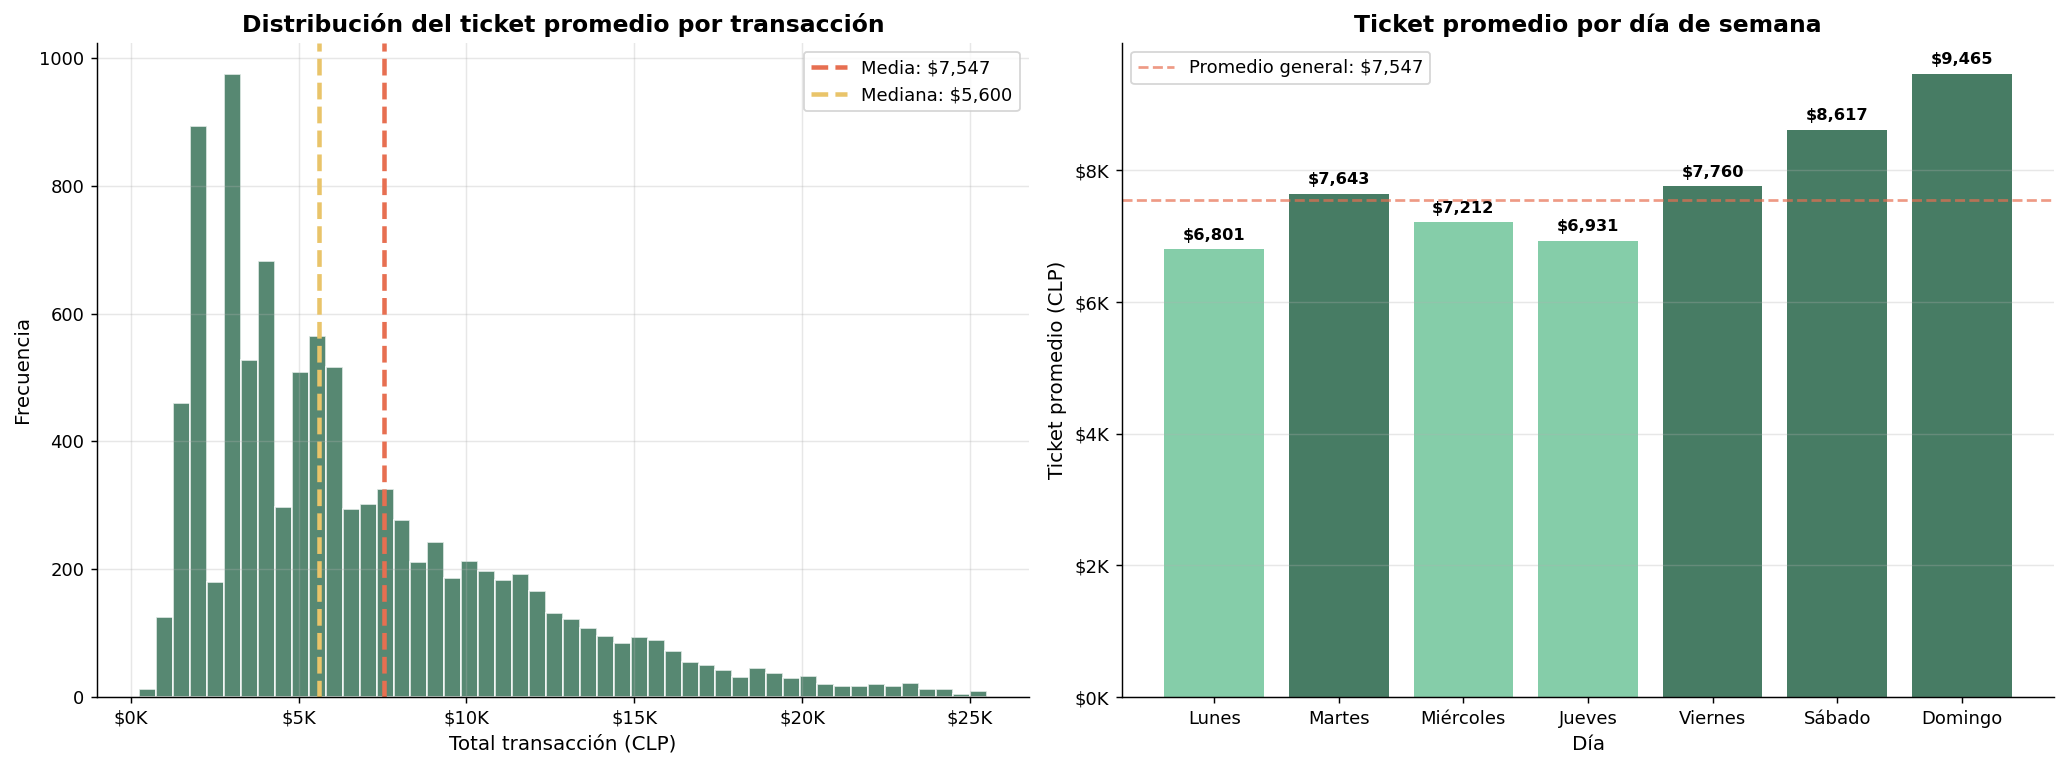

Estadísticas del ticket:
  Media:              $7,547 CLP
  Mediana:            $5,600 CLP
  Desv. estándar:     $8,178 CLP
  Máximo (sin outliers): $25,500 CLP
  Día de mayor ticket: Domingo ($9,465)


In [23]:
# ============================================================
# 7 — Distribución del ticket promedio
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ticket = df_trans['total'].dropna()
ticket_filtrado = ticket[ticket < ticket.quantile(0.98)]

axes[0].hist(ticket_filtrado, bins=50, color=VERDE, alpha=0.8, edgecolor='white')
axes[0].axvline(ticket.mean(), color=CORAL, linewidth=2.5, linestyle='--',
                label=f'Media: ${ticket.mean():,.0f}')
axes[0].axvline(ticket.median(), color=AMBER, linewidth=2.5, linestyle='--',
                label=f'Mediana: ${ticket.median():,.0f}')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
axes[0].set_title('Distribución del ticket promedio por transacción',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total transacción (CLP)', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

ticket_dia = df_trans.copy()
ticket_dia['dia'] = ticket_dia['fecha'].dt.day_name()
orden_dias_en = ['Monday','Tuesday','Wednesday','Thursday',
                 'Friday','Saturday','Sunday']
nombres_es = ['Lunes','Martes','Miércoles','Jueves',
              'Viernes','Sábado','Domingo']
ticket_dia_avg = ticket_dia.groupby('dia')['total'].mean().reindex(orden_dias_en)
ticket_dia_avg.index = nombres_es

colors_dias = [VERDE if v > ticket.mean() else VERDE3
               for v in ticket_dia_avg.values]
bars = axes[1].bar(ticket_dia_avg.index, ticket_dia_avg.values,
                   color=colors_dias, alpha=0.88)

for bar, val in zip(bars, ticket_dia_avg.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 100,
                 f'${val:,.0f}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[1].axhline(ticket.mean(), color=CORAL, linestyle='--', alpha=0.7,
                label=f'Promedio general: ${ticket.mean():,.0f}')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}K'))
axes[1].set_title('Ticket promedio por día de semana',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Día', fontsize=11)
axes[1].set_ylabel('Ticket promedio (CLP)', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT + '06_distribucion_ticket.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Estadísticas del ticket:")
print(f"  Media:              ${ticket.mean():,.0f} CLP")
print(f"  Mediana:            ${ticket.median():,.0f} CLP")
print(f"  Desv. estándar:     ${ticket.std():,.0f} CLP")
print(f"  Máximo (sin outliers): ${ticket_filtrado.max():,.0f} CLP")
print(f"  Día de mayor ticket: {ticket_dia_avg.idxmax()} (${ticket_dia_avg.max():,.0f})")

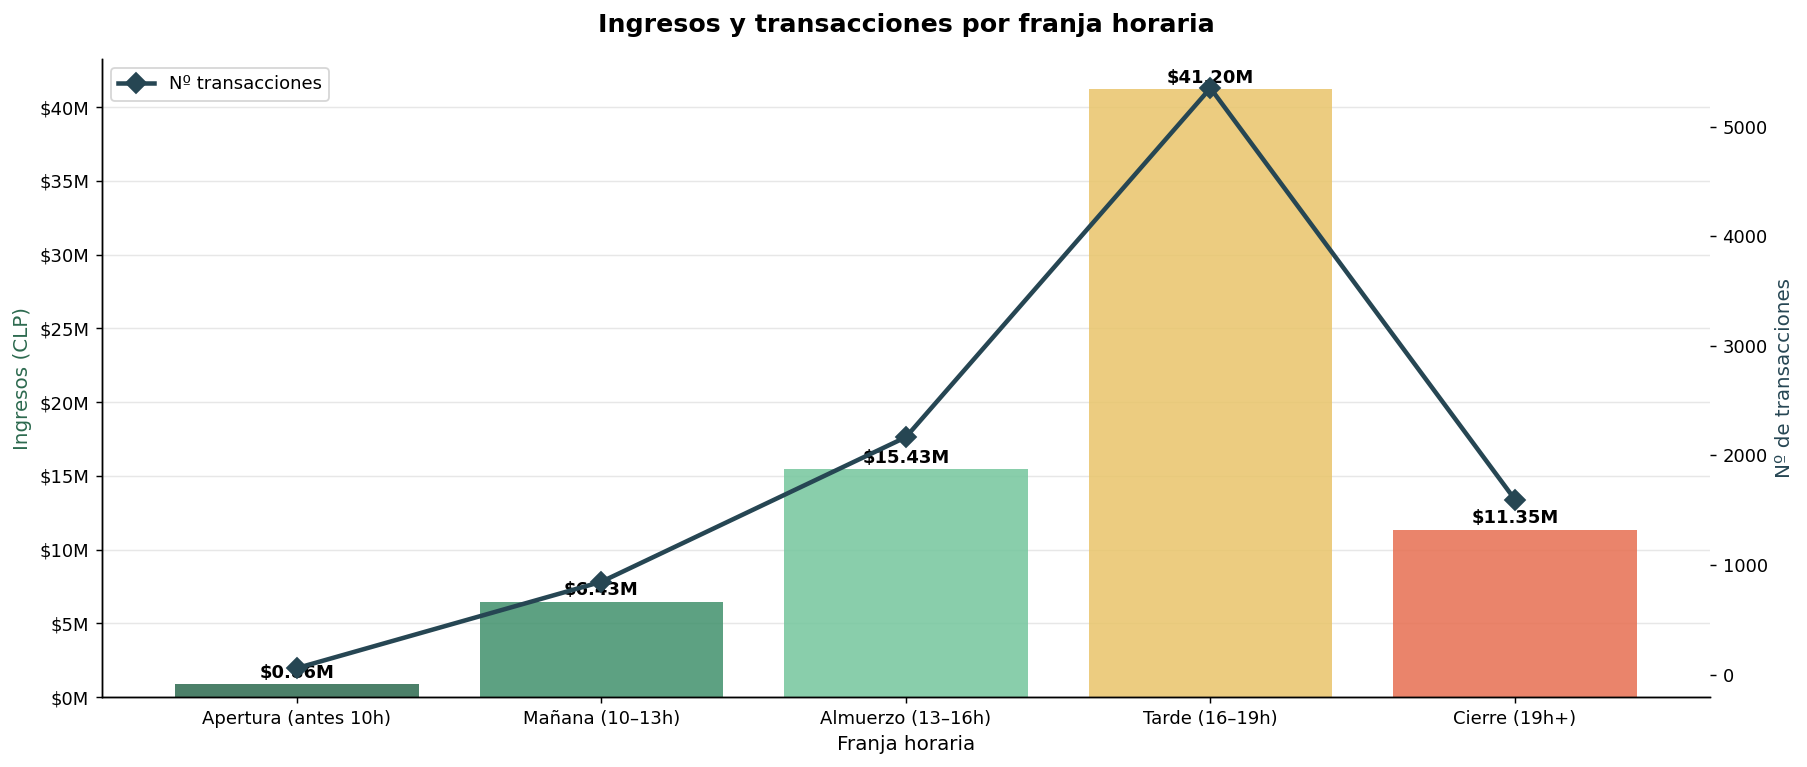

Franja de mayores ingresos:    Tarde (16–19h) ($41,199,414 CLP)
Franja con más transacciones:  Tarde (16–19h) (5,353 transacciones)

Participación por franja:
  Apertura (antes 10h)      $     858,898  (1.1%)
  Mañana (10–13h)           $   6,433,824  (8.5%)
  Almuerzo (13–16h)         $  15,434,155  (20.5%)
  Tarde (16–19h)            $  41,199,414  (54.7%)
  Cierre (19h+)             $  11,354,248  (15.1%)


In [24]:
# ============================================================
# 8 — Ingresos por franja horaria
# ============================================================
orden_franjas = [
    'Apertura (antes 10h)', 'Mañana (10–13h)',
    'Almuerzo (13–16h)',    'Tarde (16–19h)',
    'Cierre (19h+)'
]

franja_rev = df_items.groupby('franja')['revenue'].sum()\
                     .reindex(orden_franjas).fillna(0)
franja_cnt = df_items.groupby('franja')['id_transaccion'].nunique()\
                     .reindex(orden_franjas).fillna(0)

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

bars = ax1.bar(franja_rev.index, franja_rev.values,
               color=[VERDE, VERDE2, VERDE3, AMBER, CORAL],
               alpha=0.85, zorder=2)
ax2.plot(franja_rev.index, franja_cnt.values,
         color='#264653', marker='D', linewidth=2.5,
         markersize=8, zorder=3, label='Nº transacciones')

for bar, val in zip(bars, franja_rev.values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 200000,
             f'${val/1e6:.2f}M',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
ax1.set_title('Ingresos y transacciones por franja horaria',
              fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Franja horaria', fontsize=11)
ax1.set_ylabel('Ingresos (CLP)', fontsize=11, color=VERDE)
ax2.set_ylabel('Nº de transacciones', fontsize=11, color='#264653')
ax2.legend(loc='upper left', fontsize=10)
ax1.grid(axis='y', alpha=0.3, zorder=1)

plt.tight_layout()
plt.savefig(OUTPUT + '07_ingresos_franja_horaria.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Franja de mayores ingresos:    {franja_rev.idxmax()} "
      f"(${franja_rev.max():,.0f} CLP)")
print(f"Franja con más transacciones:  {franja_cnt.idxmax()} "
      f"({franja_cnt.max():,.0f} transacciones)")
print(f"\nParticipación por franja:")
for franja, val in franja_rev.items():
    pct = val / franja_rev.sum() * 100
    print(f"  {franja:<25} ${val:>12,.0f}  ({pct:.1f}%)")

In [25]:
# ============================================================
# 9 — Resumen ejecutivo de KPIs
# ============================================================
print("=" * 60)
print("   RESUMEN EJECUTIVO — CAFETERÍA ARTESANAL 2024")
print("=" * 60)

total_ing    = df_items['revenue'].sum()
total_trans  = len(df_trans)
ticket_avg   = df_trans['total'].mean()
dias_op      = (df_items['fecha'].max() - df_items['fecha'].min()).days
ing_dia      = total_ing / dias_op
productos    = df_items['producto'].nunique()
excluir_may  = ['Tiramisu stevia x 20']
top_producto = df_conteo[~df_conteo['producto'].isin(excluir_may)].iloc[0]
top_seccion  = df_secc.iloc[0]
metodo_top   = df_trans.groupby('metodo_simple')['total'].sum().idxmax()

kpis = {
    "Ingresos totales 2024":      f"${total_ing:,.0f} CLP",
    "Transacciones totales":      f"{total_trans:,}",
    "Ticket promedio":            f"${ticket_avg:,.0f} CLP",
    "Ingresos promedio diario":   f"${ing_dia:,.0f} CLP",
    "Días de operación":          f"{dias_op} días",
    "Productos únicos":           f"{productos}",
    "Producto estrella":          f"{top_producto['producto']} (${top_producto['total']:,.0f})",
    "Sección líder":              f"{top_seccion['seccion']} (${top_seccion['total']:,.0f})",
    "Método de pago principal":   f"{metodo_top}",
    "Propinas registradas":       "421",
}

for k, v in kpis.items():
    print(f"  {k:<30} {v}")

print("=" * 60)
print("\nGráficos guardados en /output/")
print("Listo para Notebook 03 — Estadística e Ingeniería de Menú")

   RESUMEN EJECUTIVO — CAFETERÍA ARTESANAL 2024
  Ingresos totales 2024          $75,280,539 CLP
  Transacciones totales          10,023
  Ticket promedio                $7,547 CLP
  Ingresos promedio diario       $281,950 CLP
  Días de operación              267 días
  Productos únicos               159
  Producto estrella              Pan dulce relleno con diseño ($9,592,000)
  Sección líder                  Panadería de autor ($11,622,400)
  Método de pago principal       Débito
  Propinas registradas           421

Gráficos guardados en /output/
Listo para Notebook 03 — Estadística e Ingeniería de Menú
